# EDA playground (personal scratch)
September scope: understand the data only. No modeling.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def find_root():
    p = Path.cwd().resolve()
    for d in [p, *p.parents]:
        if (d / 'data' / 'allstate_claims_data.csv').exists():
            return d
    raise FileNotFoundError('data/allstate_claims_data.csv not found')

df = pd.read_csv(find_root() / 'data' / 'allstate_claims_data.csv')
cat_cols = [c for c in df.columns if c.startswith('cat')]
cont_cols = [c for c in df.columns if c.startswith('cont')]
# cat* are nominal labels, not ordered
df[cat_cols] = df[cat_cols].astype('category')
print(df.shape, len(cat_cols), 'cat,', len(cont_cols), 'cont')

(188318, 132) 116 cat, 14 cont


## Target: loss

In [2]:
pcts = [.25, .5, .75, .9, .95, .99]
summary = df['loss'].describe(percentiles=pcts)
summary['skew'] = df['loss'].skew()
summary.round(3)

count    188318.000
mean       3037.338
std        2904.086
min           0.670
25%        1204.460
50%        2115.570
75%        3864.045
90%        6401.743
95%        8508.536
99%       13981.203
max      121012.250
skew          3.795
Name: loss, dtype: float64

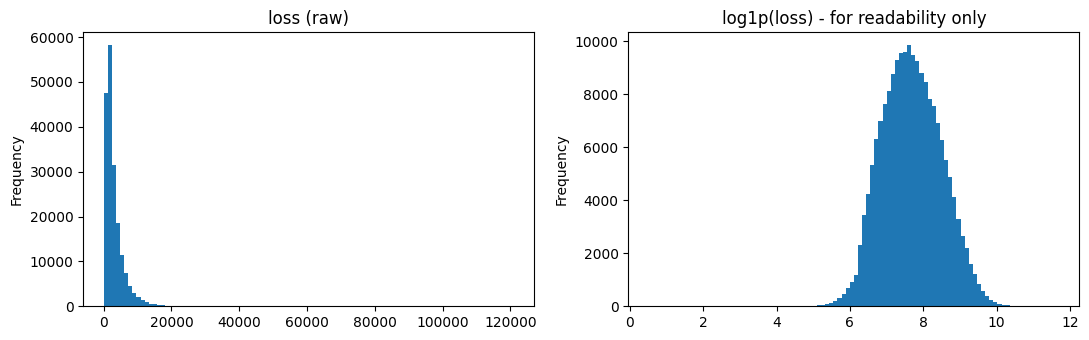

In [3]:
fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
df['loss'].plot.hist(bins=100, ax=ax[0], title='loss (raw)')
np.log1p(df['loss']).plot.hist(bins=100, ax=ax[1], title='log1p(loss) - for readability only')
plt.tight_layout()

## Categorical cardinality

In [4]:
card = df[cat_cols].nunique().sort_values(ascending=False)
print((card == 2).sum(), 'with 2 levels;', (card <= 4).sum(), 'with <=4 levels')
card.head(5)

72 with 2 levels; 88 with <=4 levels


cat116    326
cat110    131
cat109     84
cat113     61
cat112     51
dtype: int64

## Continuous vs loss (marginal association only)

In [5]:
corr = pd.DataFrame({
    'pearson_loss': df[cont_cols].corrwith(df['loss']),
    'spearman_loss': df[cont_cols].corrwith(df['loss'], method='spearman')})
corr.reindex(corr['pearson_loss'].abs().sort_values(ascending=False).index).round(3)

,pearson_loss,spearman_loss
cont2,0.142,0.080
cont7,0.120,0.055
cont3,0.111,0.068
cont11,0.100,0.054
cont12,0.099,0.054
cont6,0.041,0.020
cont4,-0.036,-0.028
cont8,0.031,0.027
cont10,0.020,0.003
cont14,0.019,0.002
